# Hari 16 — Linear Regression: Model Pertama dengan Semua Fitur

Kemarin (Hari 15) kamu sudah lihat bahwa model sederhana pakai **satu fitur** saja bisa mengalahkan baseline naive (12.953). Hari ini kita bangun model "sungguhan" pertama: Linear Regression memakai **SEMUA fitur** (`lag_1`, `lag_2`, `lag_3`, `rolling_mean_4w`, `vaksin_persen`, `bulan_1`...`bulan_12`) dari `X_train_scaled`.

In [4]:
# Cell ini sudah lengkap — memuat data dan fit Linear Regression dengan semua fitur.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X_train_scaled = pd.read_csv("X_train_scaled.csv", index_col=0, parse_dates=True)
X_test_scaled = pd.read_csv("X_test_scaled.csv", index_col=0, parse_dates=True)
y_train = pd.read_csv("y_train.csv", index_col=0, parse_dates=True).iloc[:, 0]
y_test = pd.read_csv("y_test.csv", index_col=0, parse_dates=True).iloc[:, 0]

model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)

pred_train = model_linear.predict(X_train_scaled)
pred_test = model_linear.predict(X_test_scaled)

print(f"Model dilatih dengan {X_train_scaled.shape[1]} fitur, {X_train_scaled.shape[0]} baris training")

Model dilatih dengan 17 fitur, 114 baris training


## Evaluasi: MAE vs RMSE

Dua metrik yang sering dipakai untuk regresi, keduanya bertujuan mirip tapi bereaksi beda terhadap kesalahan besar:

- **MAE (Mean Absolute Error)**: rata-rata selisih absolut. Semua kesalahan diperlakukan setara.
- **RMSE (Root Mean Squared Error)**: kesalahan dikuadratkan dulu sebelum dirata-rata, lalu diakarkan. Kesalahan besar "dihukum" lebih berat — RMSE selalu ≥ MAE, dan makin jauh jaraknya dari MAE berarti makin ada beberapa kesalahan besar yang mendominasi.

In [5]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Hitung MAE train dan MAE test dengan mean_absolute_error(y_asli, y_prediksi)
# 2. Hitung RMSE train dan RMSE test — mean_squared_error() menghasilkan MSE,
#    jadi RMSE = akar dari itu: mean_squared_error(y_asli, y_prediksi) ** 0.5
#    (pakai pangkat 0.5 atau np.sqrt(), bukan parameter squared=False —
#    parameter itu sudah/akan dihapus di versi scikit-learn terbaru)
# 3. Cetak keempat angka itu dengan rapi
# 4. Bandingkan MAE test dengan baseline (12953): hitung selisihnya dan persentase perbaikannya, 
#    misal: (12953 - mae_test) / 12953 * 100
# 5. Cetak kesimpulan: apakah model ini mengalahkan baseline, dan berapa persen perbaikannya
# Tulis kode kamu di bawah ini:
mae_train = mean_absolute_error(y_train, pred_train)
mae_test = mean_absolute_error(y_test, pred_test)
rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
rmse_test = mean_squared_error(y_test, pred_test) ** 0.5
baseline = 12953
persentase_perbaikan = (baseline - mae_test) / baseline * 100

print(f"MAE train : {mae_train:,.2f}")
print(f"MAE test  : {mae_test:,.2f}")
print(f"RMSE train: {rmse_train:,.2f}")
print(f"RMSE test : {rmse_test:,.2f}")
print(f"Perbaikan terhadap baseline: {persentase_perbaikan:.2f}%")
if mae_test < baseline:
    print("Model mengalahkan baseline.")
else:
    print("Model belum mengalahkan baseline.")

MAE train : 11,307.33
MAE test  : 7,806.56
RMSE train: 20,841.83
RMSE test : 9,975.02
Perbaikan terhadap baseline: 39.73%
Model mengalahkan baseline.


## Interpretasi Koefisien: Fitur Mana yang Paling Berpengaruh?

In [6]:
# Cell ini sudah lengkap.
koefisien = pd.Series(model_linear.coef_, index=X_train_scaled.columns)
koefisien_urut = koefisien.reindex(koefisien.abs().sort_values(ascending=False).index)

print("Koefisien diurutkan dari yang paling berpengaruh (nilai absolut terbesar):\n")
print(koefisien_urut)

Koefisien diurutkan dari yang paling berpengaruh (nilai absolut terbesar):

rolling_mean_4w    452668.096188
lag_1             -168256.611676
lag_2             -139517.517441
lag_3             -111595.239891
bulan_1             11810.248311
bulan_7             11211.833196
bulan_6              8461.969829
bulan_4             -6279.997927
bulan_10            -5572.234898
bulan_5             -5553.714241
bulan_12            -4078.737336
bulan_9             -3863.105619
bulan_2             -3736.171486
bulan_11            -3712.402979
bulan_3              2982.429143
bulan_8             -1670.115992
vaksin_persen        1370.711298
dtype: float64


**Catatan penting soal interpretasi ini:** karena fitur kontinu (`lag_1`, `lag_2`, dst) sudah di-scale (rentang mirip -2 sampai 2), sementara kolom `bulan_*` itu 0/1 (tidak di-scale), perbandingan besar-kecilnya koefisien **tidak 100% apple-to-apple**. Tapi karena rentang keduanya cukup mirip (sama-sama kira-kira dalam skala satuan kecil), ini masih memberi gambaran kasar yang cukup berguna — jangan dianggap sebagai bukti statistik yang presisi.

In [10]:
X_train_scaled[["lag_1", "lag_2", "lag_3", "rolling_mean_4w"]].corr()

,lag_1,lag_2,lag_3,rolling_mean_4w
lag_1,1.000000,0.925981,0.759518,0.975886
lag_2,0.925981,1.000000,0.926003,0.975898
lag_3,0.759518,0.926003,1.000000,0.874481
rolling_mean_4w,0.975886,0.975898,0.874481,1.000000


## Visualisasi: Prediksi vs Angka Sebenarnya

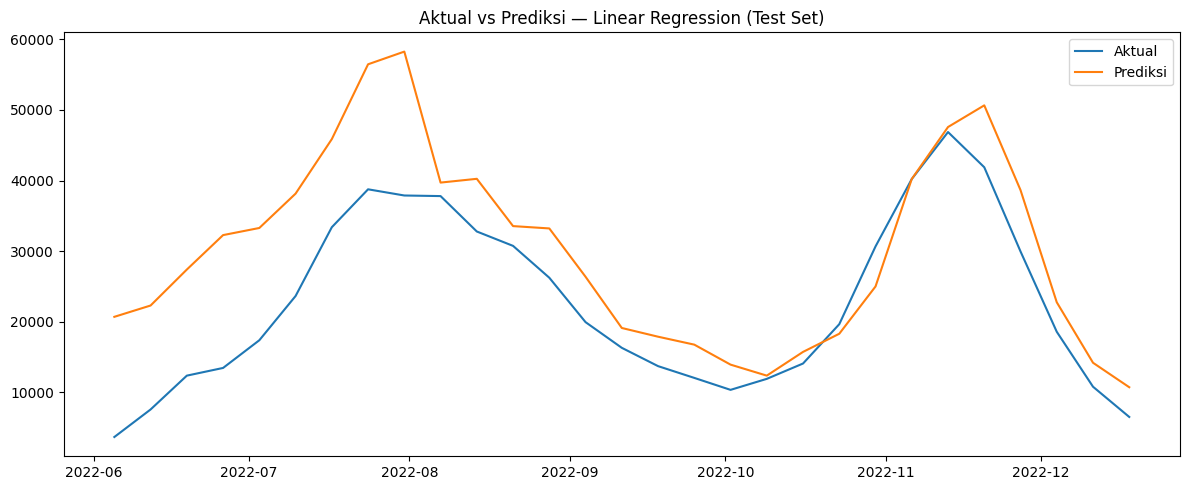

In [7]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Buat figure (plt.figure(figsize=(12, 5)))
# 2. Plot y_test (angka kasus sebenarnya) terhadap index tanggalnya, beri label "Aktual"
# 3. Plot pred_test (hasil prediksi model) di grafik yang sama, pakai
#    y_test.index sebagai sumbu x juga (karena urutannya sama), beri label "Prediksi"
# 4. Tambahkan legend, title "Aktual vs Prediksi — Linear Regression (Test Set)",
#    tight_layout, show
#
# Perhatikan baik-baik di bagian mana model paling meleset — apakah pas kasus naik tajam, turun tajam, atau di kondisi stabil?
# Tulis kode kamu di bawah ini:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Aktual")
plt.plot(y_test.index, pred_test, label="Prediksi")
plt.legend()
plt.title("Aktual vs Prediksi — Linear Regression (Test Set)")
plt.tight_layout()
plt.show()


## Analisis Residual

Residual = selisih antara nilai aktual dan prediksi (`y_test - pred_test`). Kalau model bagus, residual harusnya berfluktuasi di sekitar angka 0 **tanpa pola** — kalau ada pola jelas (misal residual selalu positif di periode tertentu), itu tanda model punya bias sistematis yang belum tertangkap.

Mean residual: -7,322.18


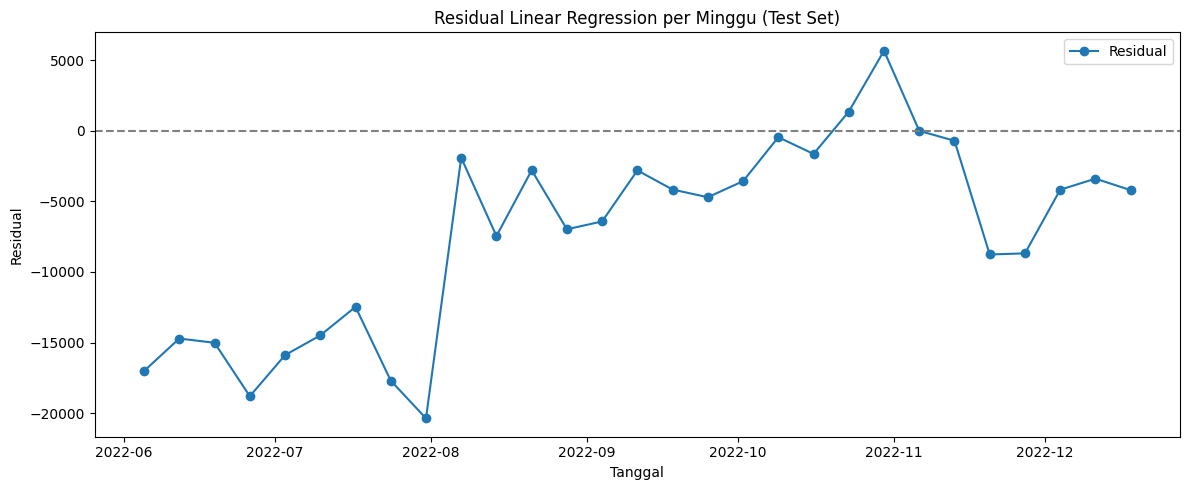

In [8]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Hitung residual = y_test - pred_test
# 2. Cetak residual.mean() — kalau jauh dari 0, model punya bias sistematis
#    (mean positif = model cenderung meremehkan/underpredict, mean negatif = sebaliknya)
# 3. Buat figure baru, plot residual terhadap index tanggalnya (pakai plt.plot atau
#    plt.scatter), tambahkan garis horizontal di y=0 dengan plt.axhline(0, color="gray", linestyle="--") sebagai referensi
# 4. Tambahkan title "Residual Linear Regression per Minggu (Test Set)", tight_layout, show
# Tulis kode kamu di bawah ini:
residual = y_test - pred_test
print(f"Mean residual: {residual.mean():,.2f}")
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, residual, marker="o", label="Residual")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Residual Linear Regression per Minggu (Test Set)")
plt.xlabel("Tanggal")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

## Refleksi Hari 16

> 1. Berapa MAE test Linear Regression kamu, dan berapa persen lebih baik dari baseline (12.953)? → **7,806.56, 39.73%**
> 2. Fitur apa dengan koefisien absolut terbesar? Apakah masuk akal secara bisnis (sesuai dugaanmu di Hari 10-11)? → **lag_1, sesuai dugaan di hari 10-11**
> 3. Dari grafik aktual vs prediksi — di bagian mana model paling meleset? Kasus naik tajam, turun tajam, atau saat stabil? → **naik tajam**
> 4. Apakah residualnya terlihat acak (bagus) atau ada pola tertentu (bias sistematis)? → **ada pola tertentu**

---
### Selanjutnya: Hari 17 — Random Forest Regressor

Linear Regression punya asumsi dasar: hubungan antar fitur dan target itu **linear**. Padahal dari Hari 6, kamu tahu data kasus COVID-19 punya pola naik-turun tajam yang kemungkinan besar **tidak linear** (gelombang Delta/Omicron naik & turun jauh lebih cepat dari pola linear biasa). Besok kita coba Random Forest — model berbasis pohon yang bisa menangkap hubungan non-linear tanpa perlu fitur di-scale (pakai `X_train` versi mentah, bukan `X_train_scaled`).